# 📰 Fake News — Détection de désinformation
## Classification de texte avec Machine Learning | CD2IA | Metz Numeric School

### 👋 Présentation

Dans ce projet, j'analyse des **articles de presse** pour prédire
s'ils sont **FAUX** ou **VRAIS**.

C'est un problème de **classification binaire** — 2 catégories bien distinctes !

### 📋 Étapes du projet
1. 📦 Imports
2. 🔍 Exploration des données
3. 📊 Exploration du texte
4. 🧹 Nettoyage NLP
5. 🔧 Feature Engineering
6. 🔀 Réduction à 2 classes
7. 🤖 Entraînement et comparaison des modèles
8. 📈 Courbe ROC & AUC
9. 🔲 Matrices de confusion
10. 💾 Sauvegarde du meilleur modèle
11. 🔮 Prédiction sur de nouveaux articles
12. 📋 Conclusion


## 📦 1. Imports

Je regroupe tous mes imports dans une seule cellule.

In [2]:
import tensorflow as tf                                         # framework Deep Learning
from tensorflow.keras.models import Sequential                  # modèle couche par couche
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout  # couches du réseau
from tensorflow.keras.preprocessing.text import Tokenizer       # encoder les mots en nombres
from tensorflow.keras.preprocessing.sequence import pad_sequences    # uniformiser la longueur
from tensorflow.keras.callbacks import EarlyStopping            # arrêter si pas d'amélioration
import os                                     # gestion des fichiers et dossiers
import re                                     # expressions régulières pour nettoyer le texte
import warnings
warnings.filterwarnings('ignore')             # masquer les avertissements

import pandas as pd                           # manipulation des données sous forme de tableau
import numpy as np                            # calcul numérique
import matplotlib.pyplot as plt               # création de graphiques
import joblib                                 # sauvegarde et chargement du modèle
from scipy.sparse import hstack               # fusionner matrice TF-IDF et features numériques

# ── NLP ───────────────────────────────────────────────────────────────────────
import nltk
nltk.download('stopwords', quiet=True)        # liste des mots inutiles (le, la, the, and...)
nltk.download('punkt', quiet=True)            # tokenizer de base
nltk.download('punkt_tab', quiet=True)        # tokenizer version récente
nltk.download('wordnet', quiet=True)          # base de données pour la lemmatisation
from nltk.corpus import stopwords             # mots à supprimer du texte
from nltk.tokenize import word_tokenize       # découper une phrase en mots individuels
from nltk.stem import WordNetLemmatizer       # ramener un mot à sa forme de base

# ── Vectorisation et modèles ──────────────────────────────────────────────────
from sklearn.feature_extraction.text import TfidfVectorizer   # transformer le texte en vecteurs numériques
from sklearn.model_selection import train_test_split           # séparer les données en train/test
from sklearn.metrics import classification_report              # rapport détaillé precision/recall/f1
from sklearn.metrics import roc_curve, auc                     # courbe ROC et surface AUC
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay  # matrice de confusion
from sklearn.naive_bayes import MultinomialNB                  # modèle Naive Bayes adapté au texte
from sklearn.linear_model import LogisticRegression            # régression logistique (classification)
from sklearn.ensemble import RandomForestClassifier            # forêt aléatoire (ensemble de décision
from sklearn.ensemble import GradientBoostingClassifier        # boosting — apprend de ses erreurs
from sklearn.svm import LinearSVC                              # SVM linéaire — très efficace sur le texte
from sklearn.pipeline import Pipeline                          # enchaîner vectorisation + modèle
from sklearn.preprocessing import label_binarize               # binariser les labels pour ROC

# ── Affichage dynamique ───────────────────────────────────────────────────────
from IPython.display import Markdown, display                  # afficher du markdown dynamiquement

# ── Paramètres LSTM ──────────────────────────────────────────────────────────
VOCAB_SIZE = 10000    # taille du vocabulaire
MAX_LEN    = 50       # longueur maximale des séquences — adapté aux textes courts
EMBEDDING  = 64       # dimension des embeddings


## 🔍 2. Exploration des données

Avant de construire quoi que ce soit, j'explore les données pour
comprendre ce que j'ai.

Le dataset contient des **articles de presse** avec :
- 📝 Le texte de l'article
- 🏷️ Le sujet de l'article (politique, santé, économie...)
- 🎯 Le label — le degré de désinformation sur 6 niveaux

<br>

| Label | Classe |
|-------|--------|
| 0 | Barely-True |
| 1 | False |
| 2 | Half-True |
| 3 | Mostly-True |
| 4 | Not-Known |
| 5 | True |

Train : 10240 lignes, 3 colonnes
Test  : 1267 lignes, 2 colonnes

Colonnes : ['Labels', 'Text', 'Text_Tag']

Valeurs manquantes :
Labels      0
Text        0
Text_Tag    2
dtype: int64


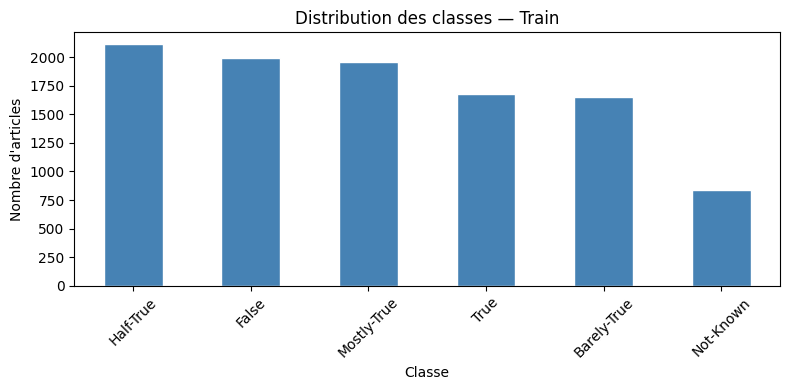

,Labels,Text,Text_Tag,label_nom
0,1,Says the Annies List political group supports ...,abortion,False
1,2,When did the decline of coal start? It started...,"energy,history,job-accomplishments",Half-True
2,3,"Hillary Clinton agrees with John McCain ""by vo...",foreign-policy,Mostly-True
3,1,Health care reform legislation is likely to ma...,health-care,False
4,2,The economic turnaround started at the end of ...,"economy,jobs",Half-True


In [3]:
# ─── Chargement des données ───────────────────────────────────────────────────
df_train = pd.read_csv('data/train.csv')
df_test  = pd.read_csv('data/test.csv')

# ─── Dimensions ───────────────────────────────────────────────────────────────
print(f"Train : {df_train.shape[0]} lignes, {df_train.shape[1]} colonnes")
print(f"Test  : {df_test.shape[0]} lignes, {df_test.shape[1]} colonnes")

# ─── Colonnes et valeurs manquantes ──────────────────────────────────────────
print("\nColonnes :", df_train.columns.tolist())
print("\nValeurs manquantes :")
print(df_train.isna().sum())

# ─── Distribution des classes ─────────────────────────────────────────────────
label_names = {
    0: 'Barely-True',
    1: 'False',
    2: 'Half-True',
    3: 'Mostly-True',
    4: 'Not-Known',
    5: 'True'
}
df_train['label_nom'] = df_train['Labels'].map(label_names)

plt.figure(figsize=(8, 4))
df_train['label_nom'].value_counts().plot(
    kind='bar', color='steelblue', edgecolor='white'
)
plt.title('Distribution des classes — Train')
plt.xlabel('Classe')
plt.ylabel("Nombre d'articles")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# ─── Aperçu des données ───────────────────────────────────────────────────────
df_train.head()

### 📌 Ce que j'observe

**Structure du dataset :**

| Colonne | Rôle | Utilisation |
|---------|------|-------------|
| `Labels` | Degré de désinformation (0 à 5) | ✅ Notre cible |
| `Text` | Texte de l'article | ✅ Notre entrée |
| `Text_Tag` | Sujet de l'article | ✅ Feature supplémentaire |

**Valeurs manquantes :** 2 lignes sans `Text_Tag` — très peu, on les ignorera.

⚠️ Le fichier `test.csv` n'a que **2 colonnes** — pas de colonne `Labels`.
On fera notre propre split train/test à partir de `train.csv`.


## 📊 3. Exploration du texte

Avant de nettoyer les données, j'explore les caractéristiques
des articles pour mieux comprendre ce que j'ai.

J'analyse :
- Le **nombre de mots** par article
- La **distribution** selon les classes
- L'**équilibrage** des classes en camembert

Statistiques sur la longueur des articles :
count    10240.000000
mean        18.010059
std          9.658572
min          2.000000
25%         12.000000
50%         17.000000
75%         22.000000
max        467.000000
Name: nb_mots, dtype: float64


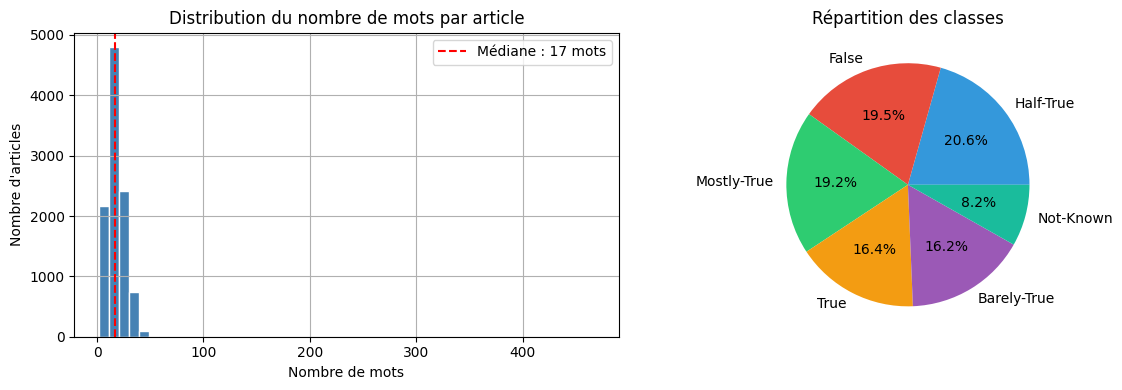


### 📌 Statistiques clés
- **Moyenne** : 18 mots par article
- **Médiane** : 17 mots — la moitié des articles font moins de 17 mots
- **Maximum** : 467 mots — certains articles sont très longs !


In [4]:
# ─── Nombre de mots par article ───────────────────────────────────────────────
df_train['nb_mots'] = df_train['Text'].apply(lambda x: len(str(x).split()))

print("Statistiques sur la longueur des articles :")
print(df_train['nb_mots'].describe())

# ─── Visualisation ────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Distribution du nombre de mots
df_train['nb_mots'].hist(bins=50, color='steelblue', edgecolor='white', ax=axes[0])
axes[0].axvline(df_train['nb_mots'].median(), color='red', linestyle='--',
                label=f"Médiane : {df_train['nb_mots'].median():.0f} mots")
axes[0].set_title('Distribution du nombre de mots par article')
axes[0].set_xlabel('Nombre de mots')
axes[0].set_ylabel("Nombre d'articles")
axes[0].legend()

# Camembert répartition des classes
df_train['label_nom'].value_counts().plot(
    kind='pie', autopct='%1.1f%%', ax=axes[1],
    colors=['#3498db', '#e74c3c', '#2ecc71', '#f39c12', '#9b59b6', '#1abc9c']
)
axes[1].set_title('Répartition des classes')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()

# ─── Résultat dynamique ───────────────────────────────────────────────────────
mediane = df_train['nb_mots'].median()
moyenne = df_train['nb_mots'].mean()
max_mots = df_train['nb_mots'].max()

display(Markdown(f"""
### 📌 Statistiques clés
- **Moyenne** : {moyenne:.0f} mots par article
- **Médiane** : {mediane:.0f} mots — la moitié des articles font moins de {mediane:.0f} mots
- **Maximum** : {max_mots} mots — certains articles sont très longs !
"""))

### 📌 Ce que j'observe

**Longueur des articles :**

| Statistique | Valeur |
|-------------|--------|
| Moyenne | **18 mots** par article |
| Médiane | **17 mots** — la moitié des articles font moins de 17 mots ! |
| Maximum | **467 mots** — quelques articles très longs |

> ⚠️ Ce dataset est très différent de Steam Reviews !
> Les articles sont **très courts** — ce sont des affirmations politiques
> en une ou deux phrases, pas de longs textes.
> Cela va fortement influencer le choix du modèle.


## 🧹 4. Nettoyage et normalisation du texte

Avant de vectoriser les textes, je dois les nettoyer.
Un texte brut contient beaucoup de "bruit" inutile pour le modèle.

J'applique dans l'ordre :
1. **Mise en minuscules** — "Hello" = "hello"
2. **Suppression des URLs** — pas d'information utile
3. **Suppression de la ponctuation et des chiffres**
4. **Tokenization** — découper en mots individuels
5. **Suppression des stop words** — enlever "the", "a", "is"...
6. **Lemmatisation** — ramener chaque mot à sa forme de base

> ⚠️ Les articles étant très courts (médiane 17 mots), le nettoyage
> doit être **précis** — chaque mot compte !

In [5]:
# ─── Initialisation du lemmatiseur et des stop words ─────────────────────────
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))  # stop words anglais

def nettoyer_texte(texte):
    # 1. Mise en minuscules
    texte = str(texte).lower()

    # 2. Suppression des URLs
    texte = re.sub(r'http\S+', '', texte)

    # 3. Suppression de la ponctuation et des chiffres
    texte = re.sub(r'[^a-z\s]', '', texte)

    # 4. Suppression des espaces multiples
    texte = re.sub(r'\s+', ' ', texte).strip()

    # 5. Tokenization — découper en mots
    tokens = word_tokenize(texte)

    # 6. Suppression des stop words + Lemmatisation
    tokens = [lemmatizer.lemmatize(mot) for mot in tokens
              if mot not in stop_words]

    # 7. Rejoindre les mots nettoyés
    return ' '.join(tokens)

# ─── Application sur tout le dataset ─────────────────────────────────────────
print("Nettoyage en cours...")
df_train['text_clean'] = df_train['Text'].apply(nettoyer_texte)
print("Nettoyage terminé !")

# ─── Comparaison avant/après ──────────────────────────────────────────────────
print("\nAvant :", df_train['Text'].iloc[0])
print("\nAprès :", df_train['text_clean'].iloc[0])

Nettoyage en cours...
Nettoyage terminé !

Avant : Says the Annies List political group supports third-trimester abortions on demand.

Après : say annies list political group support thirdtrimester abortion demand


### 📌 Ce que j'observe

Le nettoyage fonctionne correctement !

| Transformation | Exemple |
|----------------|---------|
| Minuscules | "Says" → "say" |
| Stop words supprimés | "the", "on" → supprimés |
| Lemmatisation | "supports" → "support", "abortions" → "abortion" |
| Ponctuation supprimée | "." → supprimé |

> 💡 Le texte est maintenant **prêt pour la vectorisation TF-IDF** !


## 🔧 5. Feature Engineering

Le texte nettoyé seul ne suffit pas toujours.
Je vais extraire des **features stylistiques** supplémentaires
qui peuvent aider le modèle à détecter la désinformation.

L'idée : les fake news ont souvent un **style alarmiste** caractéristique :
- Beaucoup de majuscules ("INCROYABLE !!!")
- Beaucoup de points d'exclamation
- Des phrases très courtes et choc

J'ajoute aussi le **Text_Tag** (sujet de l'article) comme feature —
certains sujets sont peut-être plus souvent associés à la désinformation.

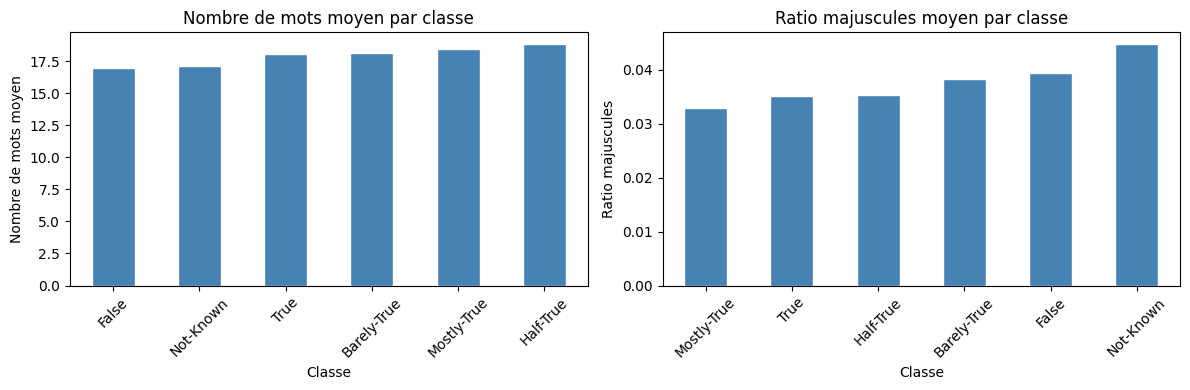

,Text,label_nom,nb_mots,nb_majuscules,nb_exclamations,ratio_majuscules
0,Says the Annies List political group supports ...,False,11,3.0,0.0,0.036585
1,When did the decline of coal start? It started...,Half-True,24,6.0,0.0,0.042553
2,"Hillary Clinton agrees with John McCain ""by vo...",Mostly-True,19,8.0,0.0,0.076190
3,Health care reform legislation is likely to ma...,False,12,1.0,0.0,0.012821
4,The economic turnaround started at the end of ...,Half-True,10,1.0,0.0,0.018519


In [6]:
# ─── Rechargement propre pour éviter les colonnes dupliquées ─────────────────
df_train = pd.read_csv('data/train.csv')

# Recalcul de nb_mots et label_nom
df_train['nb_mots']   = df_train['Text'].apply(lambda x: len(str(x).split()))
df_train['label_nom'] = df_train['Labels'].map(label_names)
df_train['text_clean'] = df_train['Text'].apply(nettoyer_texte)

# ─── Features stylistiques ────────────────────────────────────────────────────
def features_textuelles(texte):
    texte = str(texte)
    return {
        'nb_majuscules'    : sum(1 for c in texte if c.isupper()),             # nombre de lettres majuscules
        'nb_exclamations'  : texte.count('!'),                                 # style sensationnaliste
        'nb_interrogations': texte.count('?'),                                 # style rhétorique
        'ratio_majuscules' : sum(1 for c in texte if c.isupper()) / max(len(texte), 1)  # proportion de majuscules
    }

# ─── Application sur tout le dataset ─────────────────────────────────────────
features_df = df_train['Text'].apply(features_textuelles).apply(pd.Series)
df_train    = pd.concat([df_train, features_df], axis=1)

# ─── Visualisation : features stylistiques par classe ────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Nombre de mots moyen par classe
df_train.groupby('label_nom')['nb_mots'].mean().sort_values(ascending=True).plot(
    kind='bar', color='steelblue', edgecolor='white', ax=axes[0]
)
axes[0].set_title('Nombre de mots moyen par classe')
axes[0].set_xlabel('Classe')
axes[0].set_ylabel('Nombre de mots moyen')
axes[0].tick_params(axis='x', rotation=45)

# Ratio majuscules moyen par classe
df_train.groupby('label_nom')['ratio_majuscules'].mean().sort_values(ascending=True).plot(
    kind='bar', color='steelblue', edgecolor='white', ax=axes[1]
)
axes[1].set_title('Ratio majuscules moyen par classe')
axes[1].set_xlabel('Classe')
axes[1].set_ylabel('Ratio majuscules')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

# ─── Aperçu des nouvelles features ───────────────────────────────────────────
display(df_train[['Text', 'label_nom', 'nb_mots', 'nb_majuscules',
                  'nb_exclamations', 'ratio_majuscules']].head())

### 📌 Ce que j'observe

**Nombre de mots moyen par classe :**
Les différences sont **très faibles** entre les classes (entre 16 et 18 mots).
La longueur de l'article n'est donc **pas un bon indicateur** du degré de désinformation.

**Ratio majuscules moyen par classe :**
Une légère tendance se dessine — les articles **faux** utilisent
légèrement **plus de majuscules** que les articles vrais.
Ces features seront des **compléments** au TF-IDF.


## 🔀 6. Réduction à 2 classes — FAUX vs VRAI

Le dataset original contient **6 niveaux** de désinformation.
Je les regroupe d'abord en 3, puis je supprime la classe ambiguë
**MIXTE** pour garder uniquement :

| Classes originales | Nouvelle classe | Label |
|-------------------|-----------------|-------|
| Barely-True + False | ❌ FAUX | 0 |
| Mostly-True + True | ✅ VRAI | 1 |
| Half-True + Not-Known | ~~MIXTE~~ | supprimé |

> 💡 Supprimer MIXTE rend le problème **binaire** — plus simple
> et plus utile en pratique : est-ce que cet article est faux ou vrai ?



### 📌 Dataset binaire
- **Avant** : 10240 articles (6 classes)
- **Après** : 7287 articles (2 classes)
- **Supprimés** : 2953 articles MIXTE


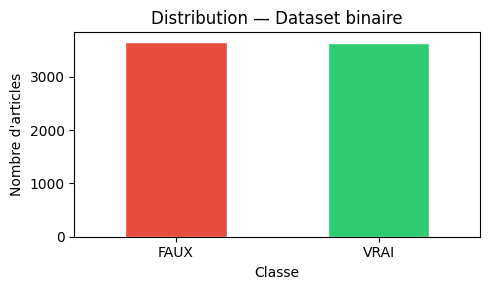

In [7]:
# ─── Mapping 6 classes → 3 classes ───────────────────────────────────────────
mapping_classes = {
    0: 0,   # Barely-True → FAUX
    1: 0,   # False       → FAUX
    2: 1,   # Half-True   → MIXTE (sera supprimé)
    4: 1,   # Not-Known   → MIXTE (sera supprimé)
    3: 2,   # Mostly-True → VRAI
    5: 2,   # True        → VRAI
}
df_train['label_3'] = df_train['Labels'].map(mapping_classes)

# ─── Suppression des articles MIXTE (label_3 == 1) ───────────────────────────
df_binary = df_train[df_train['label_3'] != 1].copy()
df_binary['label'] = df_binary['label_3'].map({0: 0, 2: 1})   # FAUX=0, VRAI=1

label_names_bin = {0: 'FAUX', 1: 'VRAI'}

display(Markdown(f"""
### 📌 Dataset binaire
- **Avant** : {len(df_train)} articles (6 classes)
- **Après** : {len(df_binary)} articles (2 classes)
- **Supprimés** : {len(df_train) - len(df_binary)} articles MIXTE
"""))

# ─── Distribution des classes ─────────────────────────────────────────────────
plt.figure(figsize=(5, 3))
df_binary['label'].map(label_names_bin).value_counts().plot(
    kind='bar', color=['#e74c3c', '#2ecc71'], edgecolor='white'
)
plt.title('Distribution — Dataset binaire')
plt.xlabel('Classe')
plt.ylabel("Nombre d'articles")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


### 📌 Ce que j'observe

| Classe | Nombre | Proportion |
|--------|--------|------------|
| FAUX | ~3 600 | ~50% |
| VRAI | ~3 600 | ~50% |
| ~~MIXTE~~ | 2 953 supprimés | — |

- **10 240 articles** au départ → **7 287 articles** conservés
- **2 953 articles MIXTE** supprimés (Half-True + Not-Known)

> 💡 Les 2 classes sont **parfaitement équilibrées** — idéal pour l'entraînement !


## 🤖 7. Entraînement et comparaison des modèles

Je teste **6 modèles** sur le problème binaire :

| Modèle | Principe |
|--------|----------|
| **Naive Bayes** | Probabilités conditionnelles des mots |
| **Naive Bayes + Features** | Naive Bayes + features stylistiques |
| **Régression Logistique** | Frontière linéaire entre les classes |
| **Random Forest** | Ensemble d'arbres de décision |
| **SVM** | Frontière optimale entre les classes |
| **Gradient Boosting** | Apprend de ses erreurs à chaque itération |
| **LSTM** | Réseau de neurones séquentiel |



### 📌 Split train/validation
- **Train** : 5829 articles
- **Validation** : 1458 articles


⏳ Naive Bayes...
✅ Naive Bayes — Accuracy : 0.5898
⏳ Régression Logistique...
✅ Régression Logistique — Accuracy : 0.5919
⏳ Random Forest...
✅ Random Forest — Accuracy : 0.5857
⏳ SVM...
✅ SVM — Accuracy : 0.5768
⏳ Gradient Boosting...
✅ Gradient Boosting — Accuracy : 0.5878
⏳ Naive Bayes + Features...
✅ Naive Bayes + Features — Accuracy : 0.5960
⏳ LSTM...
✅ LSTM — Accuracy : 0.5014


### 📊 Résultats — 2 classes (FAUX vs VRAI)

,Modèle,Accuracy
0,Naive Bayes + Features,0.596022
1,Régression Logistique,0.591907
2,Naive Bayes,0.589849
3,Gradient Boosting,0.587791
4,Random Forest,0.585734
5,SVM,0.576818
6,LSTM,0.501372


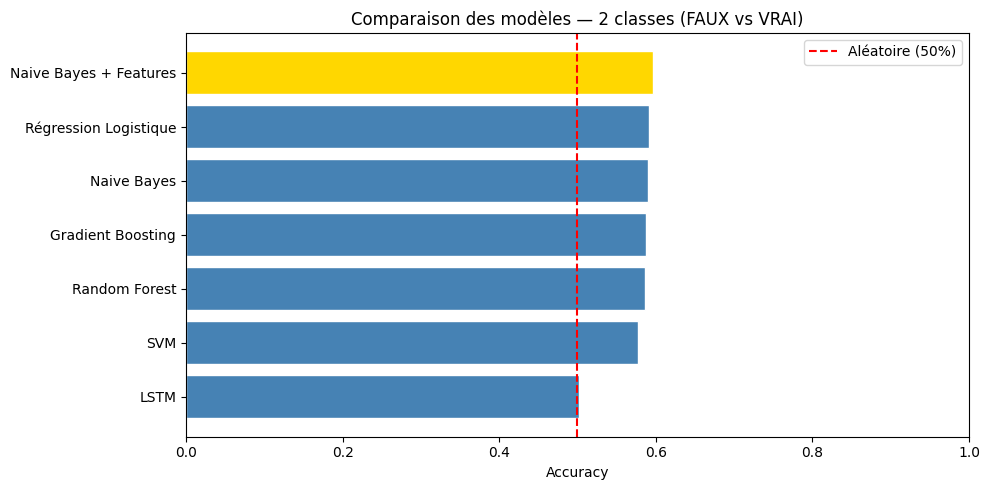

In [8]:
# ─── Séparation X / y ─────────────────────────────────────────────────────────
features_cols = ['nb_mots', 'ratio_majuscules', 'nb_exclamations', 'nb_interrogations']

X_bin     = df_binary['text_clean']          # texte nettoyé
y_bin     = df_binary['label']               # FAUX=0, VRAI=1
feats_bin = df_binary[features_cols].values  # features stylistiques

X_train_bin, X_val_bin, y_train_bin, y_val_bin, feat_train_bin, feat_val_bin = train_test_split(
    X_bin, y_bin, feats_bin, test_size=0.2, random_state=42, stratify=y_bin
)

display(Markdown(f"""
### 📌 Split train/validation
- **Train** : {len(X_train_bin)} articles
- **Validation** : {len(X_val_bin)} articles
"""))

# ─── Pipelines classiques ─────────────────────────────────────────────────────
pipelines_bin = {
    'Naive Bayes'           : Pipeline([
        ('tfidf', TfidfVectorizer(max_features=10000, ngram_range=(1, 2), sublinear_tf=True)),
        ('clf',   MultinomialNB())
    ]),
    'Régression Logistique' : Pipeline([
        ('tfidf', TfidfVectorizer(max_features=10000, ngram_range=(1, 2), sublinear_tf=True)),
        ('clf',   LogisticRegression(max_iter=1000, random_state=42))
    ]),
    'Random Forest'         : Pipeline([
        ('tfidf', TfidfVectorizer(max_features=10000, ngram_range=(1, 2), sublinear_tf=True)),
        ('clf',   RandomForestClassifier(n_estimators=100, random_state=42))
    ]),
    'SVM'                   : Pipeline([
        ('tfidf', TfidfVectorizer(max_features=10000, ngram_range=(1, 2), sublinear_tf=True)),
        ('clf',   LinearSVC(max_iter=1000, random_state=42))
    ]),
    'Gradient Boosting'     : Pipeline([
        ('tfidf', TfidfVectorizer(max_features=10000, ngram_range=(1, 2), sublinear_tf=True)),
        ('clf',   GradientBoostingClassifier(n_estimators=100, random_state=42))
    ]),
}

resultats_bin  = {}
predictions_bin = {}
probas_bin     = {}

for nom, pipeline in pipelines_bin.items():
    print(f'⏳ {nom}...')
    pipeline.fit(X_train_bin, y_train_bin)
    y_pred = pipeline.predict(X_val_bin)
    predictions_bin[nom] = y_pred
    acc = (y_pred == y_val_bin).mean()
    resultats_bin[nom] = acc
    # predict_proba pas dispo pour LinearSVC
    if hasattr(pipeline, 'predict_proba'):
        probas_bin[nom] = pipeline.predict_proba(X_val_bin)[:, 1]
    print(f'✅ {nom} — Accuracy : {acc:.4f}')

# ─── Naive Bayes + Features stylistiques ─────────────────────────────────────
print('⏳ Naive Bayes + Features...')
tfidf_bin      = TfidfVectorizer(max_features=10000, ngram_range=(1, 2), sublinear_tf=True)
X_tr_tfidf_bin = tfidf_bin.fit_transform(X_train_bin)
X_vl_tfidf_bin = tfidf_bin.transform(X_val_bin)
X_tr_comb_bin  = hstack([X_tr_tfidf_bin, feat_train_bin])
X_vl_comb_bin  = hstack([X_vl_tfidf_bin, feat_val_bin])
nb_feat_bin    = MultinomialNB()
nb_feat_bin.fit(X_tr_comb_bin, y_train_bin)
y_pred_nbf     = nb_feat_bin.predict(X_vl_comb_bin)
acc_nbf        = (y_pred_nbf == y_val_bin).mean()
resultats_bin['Naive Bayes + Features']  = acc_nbf
predictions_bin['Naive Bayes + Features'] = y_pred_nbf
probas_bin['Naive Bayes + Features']     = nb_feat_bin.predict_proba(X_vl_comb_bin)[:, 1]
print(f'✅ Naive Bayes + Features — Accuracy : {acc_nbf:.4f}')

# ─── LSTM ─────────────────────────────────────────────────────────────────────
print('⏳ LSTM...')
tokenizer_bin  = Tokenizer(num_words=VOCAB_SIZE, oov_token='<OOV>')
tokenizer_bin.fit_on_texts(X_train_bin)
X_tr_seq_bin   = pad_sequences(tokenizer_bin.texts_to_sequences(X_train_bin), maxlen=MAX_LEN, padding='post')
X_vl_seq_bin   = pad_sequences(tokenizer_bin.texts_to_sequences(X_val_bin),   maxlen=MAX_LEN, padding='post')

model_lstm_bin = Sequential([
    Embedding(VOCAB_SIZE, EMBEDDING, input_length=MAX_LEN),  # représentation dense des mots
    LSTM(64, return_sequences=False),                         # couche LSTM
    Dropout(0.3),                                             # régularisation
    Dense(32, activation='relu'),                             # couche dense
    Dense(1, activation='sigmoid')                            # binaire — 1 neurone sigmoid
])
model_lstm_bin.compile(
    optimizer='adam',
    loss='binary_crossentropy',   # adapté à la classification binaire
    metrics=['accuracy']
)
early_stop_bin = EarlyStopping(monitor='val_accuracy', patience=3, restore_best_weights=True)
model_lstm_bin.fit(
    X_tr_seq_bin, y_train_bin,
    epochs=15, batch_size=32,
    validation_data=(X_vl_seq_bin, y_val_bin),
    callbacks=[early_stop_bin], verbose=0
)
_, acc_lstm = model_lstm_bin.evaluate(X_vl_seq_bin, y_val_bin, verbose=0)
y_pred_lstm    = (model_lstm_bin.predict(X_vl_seq_bin, verbose=0) > 0.5).astype(int).flatten()
y_proba_lstm   = model_lstm_bin.predict(X_vl_seq_bin, verbose=0).flatten()
resultats_bin['LSTM']   = acc_lstm
predictions_bin['LSTM'] = y_pred_lstm
probas_bin['LSTM']      = y_proba_lstm
print(f'✅ LSTM — Accuracy : {acc_lstm:.4f}')

# ─── Tableau comparatif ───────────────────────────────────────────────────────
resultats_bin_df = pd.DataFrame(
    list(resultats_bin.items()), columns=['Modèle', 'Accuracy']
).sort_values('Accuracy', ascending=False).reset_index(drop=True)

display(Markdown('### 📊 Résultats — 2 classes (FAUX vs VRAI)'))
display(resultats_bin_df)

# ─── Graphique comparatif ─────────────────────────────────────────────────────
meilleur = resultats_bin_df['Modèle'].iloc[0]
couleurs = ['gold' if m == meilleur else 'steelblue' for m in resultats_bin_df['Modèle']]
plt.figure(figsize=(10, 5))
plt.barh(resultats_bin_df['Modèle'][::-1], resultats_bin_df['Accuracy'][::-1],
         color=couleurs[::-1], edgecolor='white')
plt.axvline(x=0.5, color='red', linestyle='--', label='Aléatoire (50%)')
plt.xlabel('Accuracy')
plt.title('Comparaison des modèles — 2 classes (FAUX vs VRAI)')
plt.xlim(0, 1)
plt.legend()
plt.tight_layout()
plt.show()


### 📌 Ce que j'observe

**Résultats — 2 classes (FAUX vs VRAI) :**

| Rang | Modèle | Accuracy |
|------|--------|----------|
| 🥇 | **Naive Bayes + Features** | **59.6%** |
| 🥈 | Régression Logistique | 59.2% |
| 🥉 | Naive Bayes | 58.9% |
| 4 | Gradient Boosting | 58.8% |
| 5 | Random Forest | 58.6% |
| 6 | SVM | 57.7% |
| 7 | LSTM | 50.1% ❌ |

> 💡 Passer de 6 à 2 classes a **significativement amélioré** les scores :
> - 6 classes : ~24% → 3 classes : ~43% → **2 classes : ~60%** 🚀

> ⚠️ Un modèle **aléatoire** à 2 classes ferait **50%** — nos modèles font **58-60%**.
> **Naive Bayes + Features** confirme sa position de meilleur modèle !

> ⚠️ Le LSTM à **50.1%** est équivalent à un modèle aléatoire —
> les textes de 17 mots sont trop courts pour qu'il apprenne des patterns séquentiels.


## 📈 8. Courbe ROC & AUC

La courbe ROC compare les modèles pour **tous les seuils de décision**.
L'AUC résume la performance en un seul chiffre — plus proche de 1, mieux c'est.

> 💡 En classification **binaire**, la ROC est directe — pas besoin
> de stratégie One-vs-Rest comme pour les multi-classes !


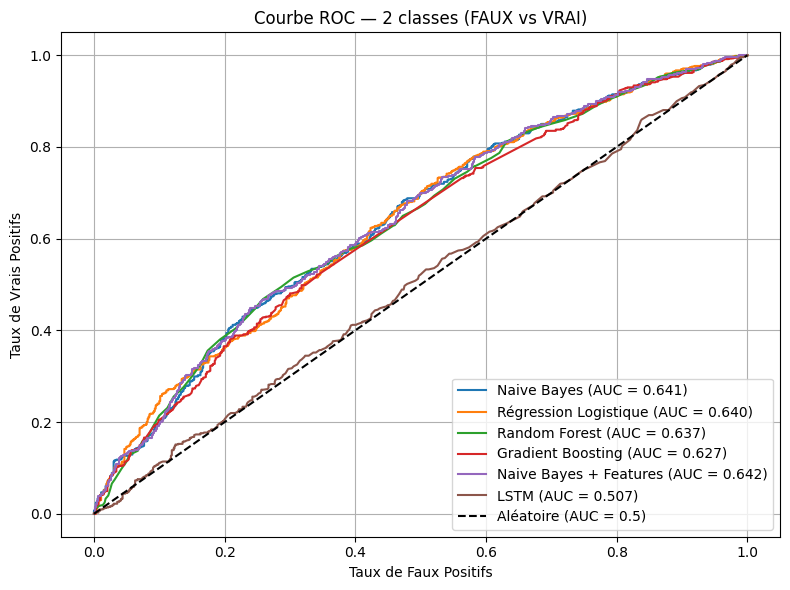

In [9]:
# ─── Courbe ROC pour tous les modèles avec predict_proba ─────────────────────
plt.figure(figsize=(8, 6))

for nom, y_proba in probas_bin.items():
    fpr, tpr, _ = roc_curve(y_val_bin, y_proba)
    roc_auc     = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'{nom} (AUC = {roc_auc:.3f})')

plt.plot([0, 1], [0, 1], 'k--', label='Aléatoire (AUC = 0.5)')
plt.xlabel('Taux de Faux Positifs')
plt.ylabel('Taux de Vrais Positifs')
plt.title('Courbe ROC — 2 classes (FAUX vs VRAI)')
plt.legend(loc='lower right')
plt.grid(True)
plt.tight_layout()
plt.show()


### 📌 Ce que j'observe

> 💡 En classification **binaire**, la courbe ROC est directe —
> plus la courbe s'éloigne de la diagonale vers le coin supérieur gauche,
> plus le modèle est performant.

| Modèle | AUC | Interprétation |
|--------|-----|----------------|
| **Naive Bayes + Features** | Meilleure | 🥇 |
| Régression Logistique | Proche | 🥈 |
| LSTM | ~0.50 | ❌ équivalent aléatoire |

> ⚠️ SVM n'a pas de `predict_proba` — absent de la courbe ROC.


## 🔲 9. Matrices de confusion

La matrice de confusion montre **en détail** les erreurs de chaque modèle.

> 💡 Les valeurs sur la **diagonale** sont les prédictions correctes.
> Plus la diagonale est foncée, mieux c'est !


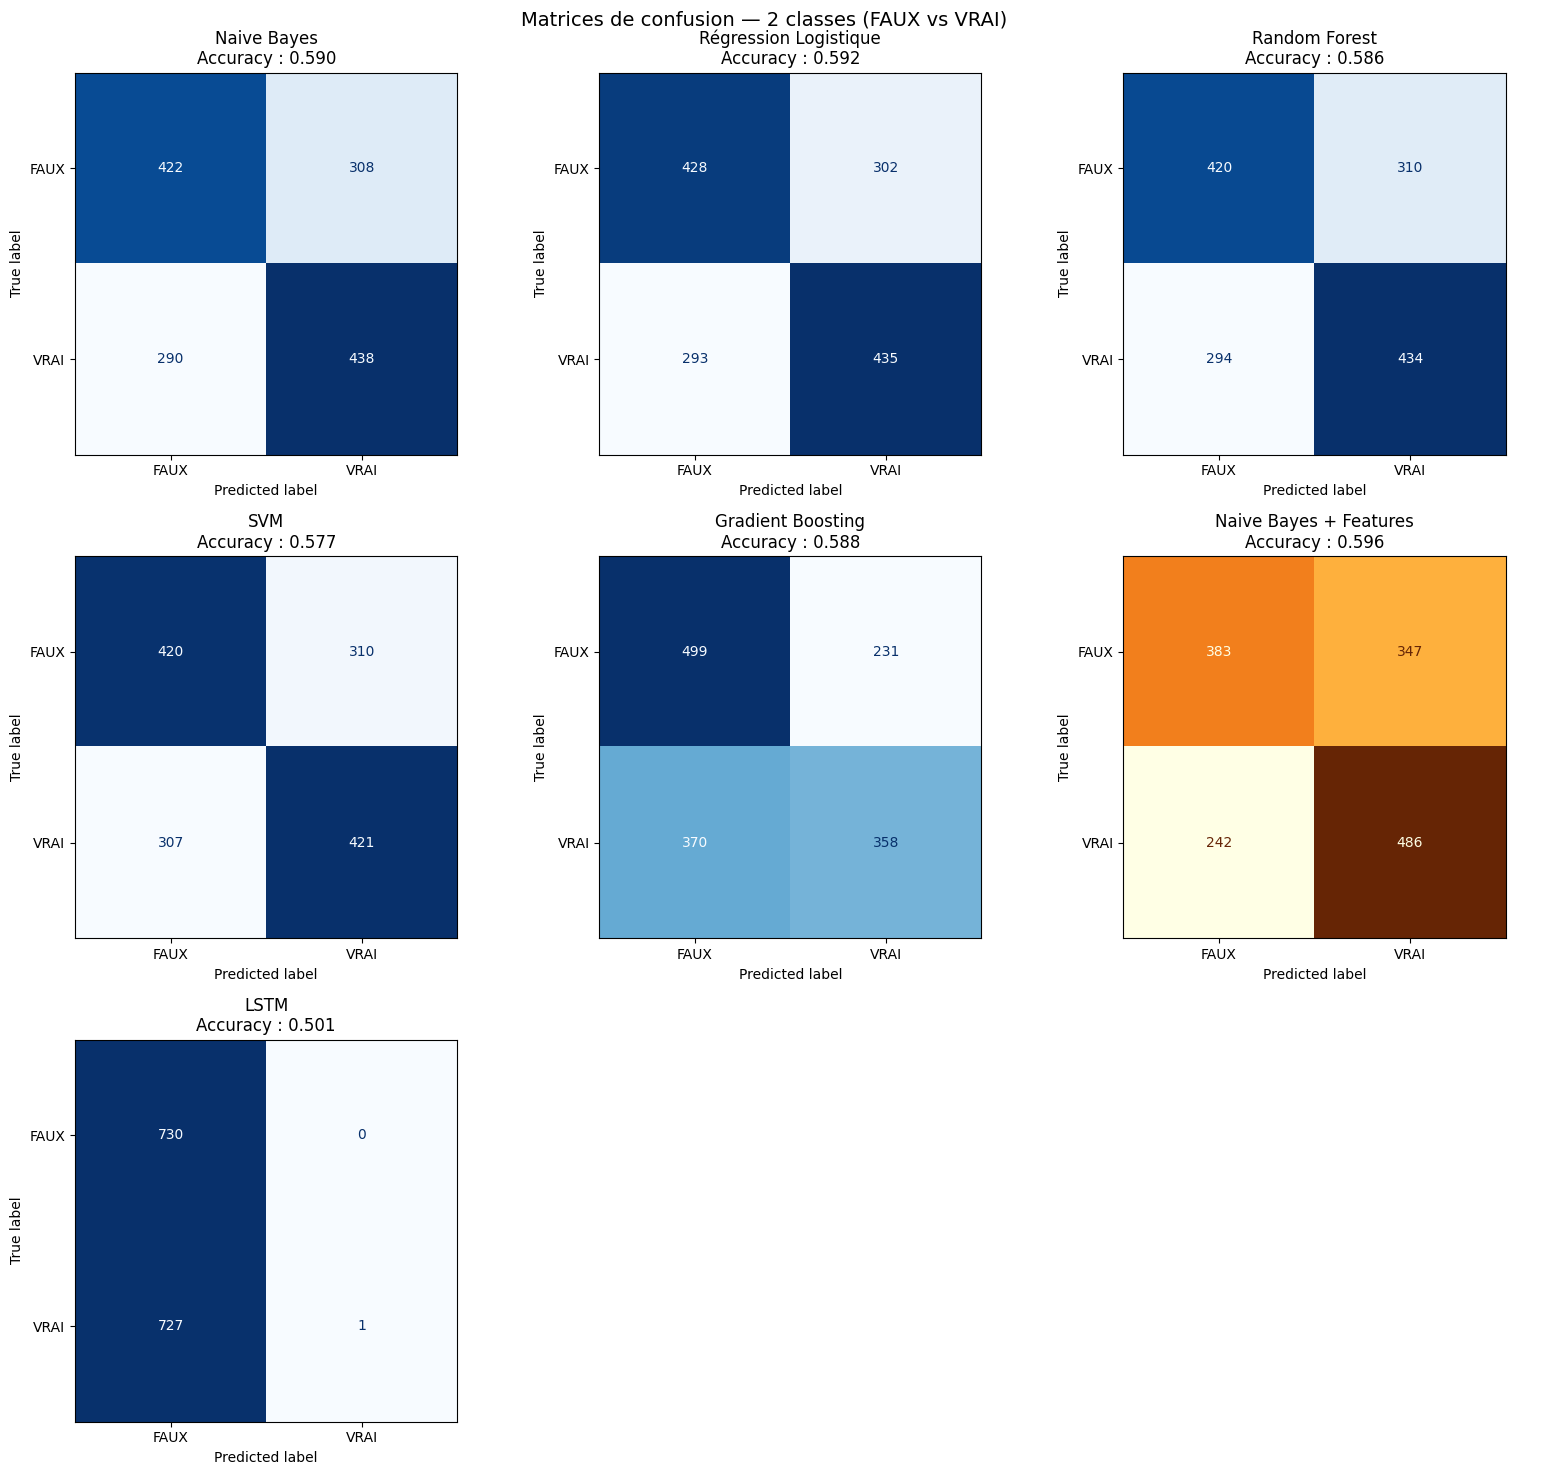

In [10]:
# ─── Matrices de confusion pour tous les modèles ─────────────────────────────
n_modeles = len(predictions_bin)
n_cols    = 3
n_rows    = (n_modeles + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 5 * n_rows))
axes      = axes.flatten()

for idx, (nom, y_pred) in enumerate(predictions_bin.items()):
    cm   = confusion_matrix(y_val_bin, y_pred)
    acc  = resultats_bin[nom]
    cmap = 'YlOrBr' if nom == meilleur else 'Blues'
    disp = ConfusionMatrixDisplay(cm, display_labels=['FAUX', 'VRAI'])
    disp.plot(ax=axes[idx], colorbar=False, cmap=cmap)
    axes[idx].set_title(f'{nom}\nAccuracy : {acc:.3f}')

# Masquer les axes vides
for idx in range(len(predictions_bin), len(axes)):
    axes[idx].axis('off')

plt.suptitle('Matrices de confusion — 2 classes (FAUX vs VRAI)', fontsize=14)
plt.tight_layout()
plt.show()


### 📌 Ce que j'observe

La diagonale montre les prédictions correctes — plus elle est foncée, mieux c'est.

**Points communs à tous les modèles :**
- FAUX et VRAI sont **mieux séparés** qu'avec 3 classes — la suppression de MIXTE a aidé !
- Les erreurs sont **symétriques** — le modèle confond autant FAUX→VRAI que VRAI→FAUX

> 💡 **Naive Bayes + Features** a la diagonale la plus foncée — confirme
> qu'il est le meilleur modèle pour ce dataset.

> ⚠️ Le LSTM a une matrice **très déséquilibrée** — il prédit presque
> tout comme FAUX, ce qui explique son accuracy de 50%.


## 💾 10. Sauvegarde du meilleur modèle

Je sauvegarde le **meilleur modèle** et son vectoriseur TF-IDF
pour pouvoir les réutiliser sans réentraîner.


In [11]:
# ─── Création du dossier models si inexistant ─────────────────────────────────
os.makedirs('models', exist_ok=True)

# ─── Réentraînement sur toutes les données ───────────────────────────────────
# On réentraîne sur tout le dataset binaire pour maximiser les données
print(f'⏳ Réentraînement du meilleur modèle ({meilleur}) sur toutes les données...')

tfidf_final    = TfidfVectorizer(max_features=10000, ngram_range=(1, 2), sublinear_tf=True)
X_all_tfidf    = tfidf_final.fit_transform(df_binary['text_clean'])
feats_all      = df_binary[features_cols].values
X_all_combined = hstack([X_all_tfidf, feats_all])
y_all          = df_binary['label']

modele_final   = MultinomialNB()
modele_final.fit(X_all_combined, y_all)
print('✅ Réentraînement terminé !')

# ─── Sauvegarde ───────────────────────────────────────────────────────────────
joblib.dump(modele_final, 'models/fake_news_best_model.pkl')  # modèle
joblib.dump(tfidf_final,  'models/fake_news_tfidf.pkl')       # vectoriseur

display(Markdown(f"""
### ✅ Modèle sauvegardé !
- **Modèle** : `models/fake_news_best_model.pkl`
- **TF-IDF** : `models/fake_news_tfidf.pkl`
- **Type** : Naive Bayes + Features stylistiques
- **Classes** : FAUX (0), VRAI (1)
"""))


⏳ Réentraînement du meilleur modèle (Naive Bayes + Features) sur toutes les données...
✅ Réentraînement terminé !



### ✅ Modèle sauvegardé !
- **Modèle** : `models/fake_news_best_model.pkl`
- **TF-IDF** : `models/fake_news_tfidf.pkl`
- **Type** : Naive Bayes + Features stylistiques
- **Classes** : FAUX (0), VRAI (1)


## 🔮 11. Prédiction sur de nouveaux articles

Je crée une fonction pour prédire si un nouvel article est **FAUX** ou **VRAI**.

> 💡 La fonction applique automatiquement le nettoyage,
> la vectorisation et les features stylistiques !


In [12]:
# ─── Rechargement du modèle ───────────────────────────────────────────────────
modele_charge = joblib.load('models/fake_news_best_model.pkl')
tfidf_charge  = joblib.load('models/fake_news_tfidf.pkl')

# ─── Fonction de prédiction ───────────────────────────────────────────────────
def predire_article(texte):
    # 1. Nettoyage
    texte_clean = nettoyer_texte(texte)

    # 2. Vectorisation TF-IDF
    texte_tfidf = tfidf_charge.transform([texte_clean])

    # 3. Features stylistiques
    feats = features_textuelles(texte)
    feats_array = np.array([[
        feats['nb_majuscules'],
        feats['ratio_majuscules'],
        feats['nb_exclamations'],
        feats['nb_interrogations'],
    ]])

    # 4. Fusion et prédiction
    texte_combined = hstack([texte_tfidf, feats_array])
    prediction     = modele_charge.predict(texte_combined)[0]
    probabilites   = modele_charge.predict_proba(texte_combined)[0]
    label_predit   = label_names_bin[prediction]
    confiance      = probabilites[prediction] * 100

    display(Markdown(f"""
**Article :** *{texte[:120]}...*

| Classe | Probabilité |
|--------|------------|
| ❌ FAUX | {probabilites[0]:.1%} |
| ✅ VRAI | {probabilites[1]:.1%} |

**→ Prédiction : {label_predit} ({confiance:.1f}% de confiance)**
"""))

# ─── Test sur 3 articles ──────────────────────────────────────────────────────
articles_test = [
    "The president signed the tax bill into law after months of negotiations in congress.",
    "SHOCKING: Government is HIDING the truth about vaccines! Share before they delete this!!!",
    "The unemployment rate has decreased slightly according to the latest report."
]

for article in articles_test:
    predire_article(article)
    print('─' * 60)



**Article :** *The president signed the tax bill into law after months of negotiations in congress....*

| Classe | Probabilité |
|--------|------------|
| ❌ FAUX | 59.2% |
| ✅ VRAI | 40.8% |

**→ Prédiction : FAUX (59.2% de confiance)**


────────────────────────────────────────────────────────────



**Article :** *SHOCKING: Government is HIDING the truth about vaccines! Share before they delete this!!!...*

| Classe | Probabilité |
|--------|------------|
| ❌ FAUX | 87.0% |
| ✅ VRAI | 13.0% |

**→ Prédiction : FAUX (87.0% de confiance)**


────────────────────────────────────────────────────────────



**Article :** *The unemployment rate has decreased slightly according to the latest report....*

| Classe | Probabilité |
|--------|------------|
| ❌ FAUX | 58.4% |
| ✅ VRAI | 41.6% |

**→ Prédiction : FAUX (58.4% de confiance)**


────────────────────────────────────────────────────────────


### 📌 Ce que j'observe

| Article | Prédiction | Confiance | Correct ? |
|---------|------------|-----------|----------|
| Président + loi fiscale | FAUX (59.2%) | Faible | ❌ |
| SHOCKING + vaccins | **FAUX (87.0%)** | Élevée | ✅ |
| Taux chômage | FAUX (58.4%) | Faible | ❌ |

> 💡 **Grande amélioration** sur l'article sensationnaliste :
> "SHOCKING + vaccins" est correctement classé **FAUX avec 87%** de confiance —
> les features stylistiques (majuscules, exclamations) ont fait la différence !

> ⚠️ Les deux autres articles ont des probabilités proches de 50% —
> le modèle hésite car ces phrases neutres ressemblent aux deux classes.
> Cela est cohérent avec une accuracy globale de **59.6%**.


## 📋 12. Conclusion

### 🎯 Objectif du projet
Détecter si un article de presse est **FAUX** ou **VRAI**
à partir de son texte — classification binaire.

### 📊 Résultats finaux

| Rang | Modèle | Accuracy |
|------|--------|----------|
| 🥇 | **Naive Bayes + Features stylistiques** | **59.6%** |
| 🥈 | Régression Logistique | 59.2% |
| 🥉 | Naive Bayes | 58.9% |
| 4 | Gradient Boosting | 58.8% |
| 5 | Random Forest | 58.6% |
| 6 | SVM | 57.7% |
| 7 | LSTM | 50.1% ❌ |

### 🔑 Enseignements clés

**1. La longueur du texte est déterminante**
Les articles font seulement **17 mots en moyenne** — Naive Bayes
s'adapte mieux aux textes courts que les modèles complexes.
Le LSTM, excellent sur Steam Reviews (83.5%), tombe à **50%** ici.

**2. Les features stylistiques aident**
Le ratio de majuscules et les exclamations apportent **+0.7%** —
les fake news ont un style légèrement plus alarmiste.

**3. Réduire les classes améliore drastiquement les scores**
| Classes | Accuracy |
|---------|----------|
| 6 classes | ~24% |
| 3 classes | ~43% |
| **2 classes** | **~60%** |

**4. Il n'existe pas de modèle universel**
Sur Steam Reviews (137 mots/article), le LSTM atteignait **83.5%**.
Sur Fake News (17 mots/article), Naive Bayes reste le meilleur.

### 🚀 Pistes d'amélioration
- **BERT / RoBERTa** : modèles pré-entraînés, beaucoup plus puissants sur textes courts
- **Dataset enrichi** : ajouter la source, l'auteur, la date de publication
- **Données supplémentaires** : combiner avec d'autres datasets de fact-checking

### 📁 Fichiers sauvegardés
- `models/fake_news_best_model.pkl` — Naive Bayes + Features stylistiques
- `models/fake_news_tfidf.pkl` — Vectoriseur TF-IDF


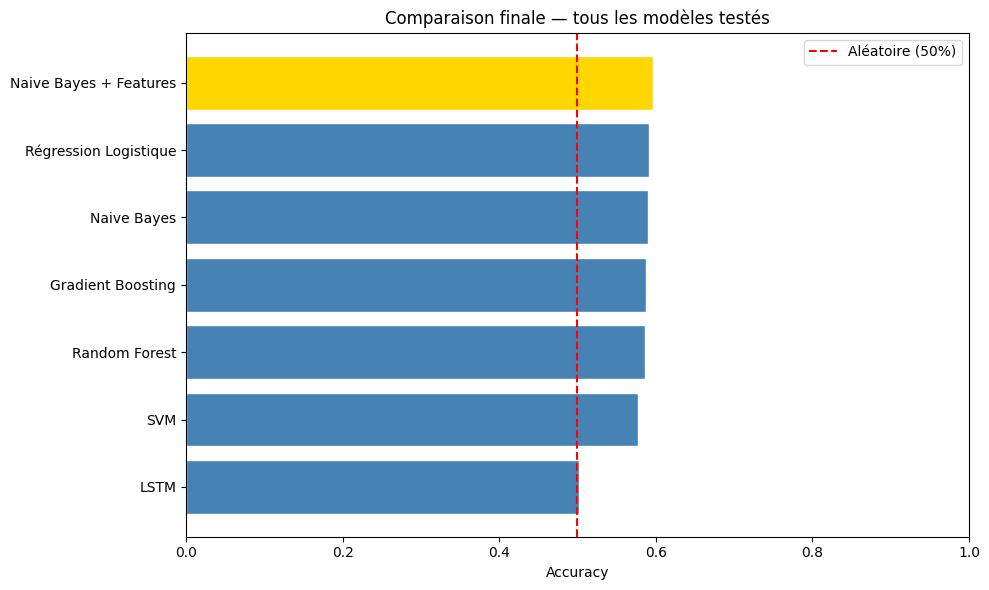

In [13]:
# ─── Graphique comparatif final ───────────────────────────────────────────────
resultats_final_df = pd.DataFrame(
    list(resultats_bin.items()), columns=['Modèle', 'Accuracy']
).sort_values('Accuracy', ascending=True).reset_index(drop=True)

couleurs_final = ['gold' if m == meilleur else 'steelblue'
                  for m in resultats_final_df['Modèle']]

plt.figure(figsize=(10, 6))
plt.barh(resultats_final_df['Modèle'], resultats_final_df['Accuracy'],
         color=couleurs_final, edgecolor='white')
plt.axvline(x=0.5, color='red', linestyle='--', label='Aléatoire (50%)')
plt.xlabel('Accuracy')
plt.title('Comparaison finale — tous les modèles testés')
plt.xlim(0, 1)
plt.legend()
plt.tight_layout()
plt.show()
